In [1]:
import sys

import polars as pl
import torch


from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule
from modeling_module.data_loader.MultiPartExoDataModule import MultiPartExoDataModule

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

save_dir = DIR + 'fit/model_validation'


In [13]:
from modeling_module.utils.date_util import DateUtil

ETT1 = (pl.read_csv(DIR + 'csv/ETTm1.csv')
    .with_columns(pl.col('date').str.strptime(pl.Datetime).dt.strftime('%Y%m%d').cast(pl.Int64).alias("date"))
    .with_columns(pl.col('date').map_elements(DateUtil.yyyymmdd_to_date).alias('date'))
    .with_columns(pl.col('date').map_elements(DateUtil.date_to_yyyyww).alias('date'))
    .group_by('date')
    .agg([
        pl.col('HUFL').sum().alias('HUFL'),
        pl.col("HULL").sum().alias("HULL"),
        pl.col("MUFL").sum().alias('MUFL'),
        pl.col("MULL").sum().alias("MULL"),
        pl.col("LUFL").sum().alias("LUFL"),
        pl.col("LULL").sum().alias("LULL"),
    ])
    .sort(pl.col('date'))
    .with_columns(pl.col('date').cast(pl.Utf8).alias('date'))
)
ETT1

/var/folders/py/xgf_87rd5nz9rsbc143wp9qc0000gn/T/ipykernel_71998/2120194689.py:5: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(pl.col('date').map_elements(DateUtil.yyyymmdd_to_date).alias('date'))
/var/folders/py/xgf_87rd5nz9rsbc143wp9qc0000gn/T/ipykernel_71998/2120194689.py:6: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  .with_columns(pl.col('date').map_elements(DateUtil.date_to_yyyyww).alias('date'))


date,HUFL,HULL,MUFL,MULL,LUFL,LULL
str,f64,f64,f64,f64,f64,f64
"""201626""",2311.128006,1130.671999,1382.126996,526.725,913.523003,484.041
"""201627""",7588.643998,3224.866989,5219.673993,1582.379999,2292.125,1198.681993
"""201628""",6781.434989,1921.047,4764.748991,837.805999,1945.089006,755.114998
"""201629""",8145.419983,2169.825994,5634.119998,933.213999,2456.862999,813.703998
"""201630""",10762.791055,1617.826012,7366.708065,53.752999,3308.713985,914.968995
…,…,…,…,…,…,…
"""201822""",5376.31502,2941.19001,2912.394022,1567.766012,2365.525024,938.596002
"""201823""",4311.382002,2786.484996,1913.026988,1504.964002,2314.098002,897.200001
"""201824""",3403.36599,3248.642994,731.767987,1796.956003,2600.093002,1044.473996


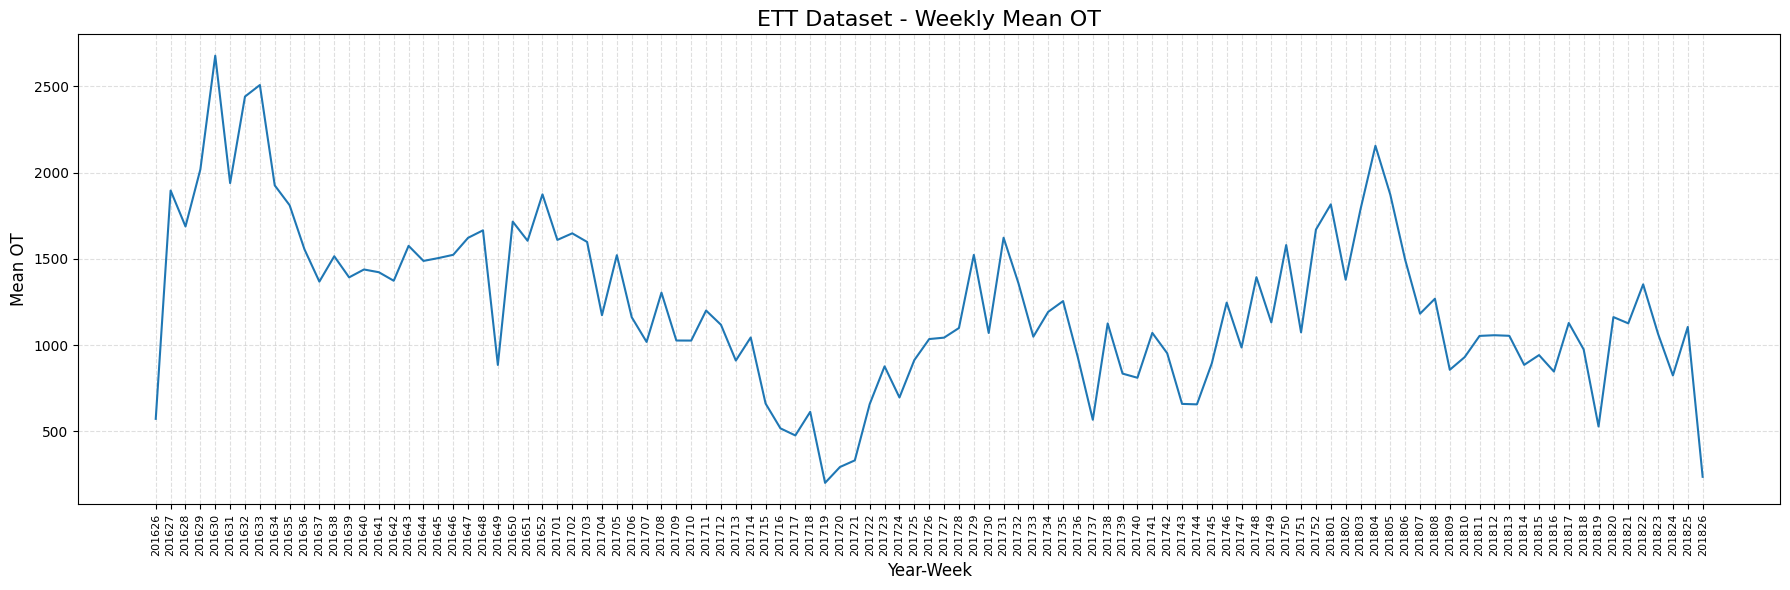

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize = (18, 6))
plt.plot(ETT1['date'], ETT1['HUFL'])
plt.xticks(rotation = 90, fontsize = 8)
plt.title('ETT Dataset - Weekly Mean OT', fontsize = 16)
plt.xlabel('Year-Week', fontsize = 12)
plt.ylabel('Mean OT', fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.4)

plt.tight_layout()
plt.show()

In [4]:
ETT1_sample = (ETT1
                .select(['date', 'HUFL'])
                .with_columns(pl.lit('A').alias('unique_id'))
               )
ETT1_sample

date,HUFL,unique_id
str,f64,str
"""201626""",571.869003,"""A"""
"""201627""",1896.068002,"""A"""
"""201628""",1687.688998,"""A"""
"""201629""",2018.637999,"""A"""
"""201630""",2677.870023,"""A"""
…,…,…
"""201822""",1351.717005,"""A"""
"""201823""",1065.257003,"""A"""
"""201824""",823.513994,"""A"""


In [5]:
plan_yyyyww = 201801
lookback = 27
horizon = 27

data_module = MultiPartExoDataModule(
    ETT1_sample,
    part_col = 'unique_id',
    date_col = 'date',
    qty_col = 'HUFL',
    lookback = lookback,
    horizon = horizon,
    is_running = True
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

[TrainingDataset] missing past_exo_cont col: sequence -> skip
[TrainingDataset] missing past_exo_cont col: age_w -> skip
[TrainingDataset] missing past_exo_cont col: in_warranty -> skip
[TrainingDataset] missing past_exo_cont col: weeks_to_warranty_end -> skip
[TrainingDataset] missing past_exo_cont col: cumsum_qty -> skip
[TrainingDataset] missing past_exo_cat col: site_id -> skip


In [6]:
print("len(train_dataset) =", len(data_module.train_dataset))
print("len(val_dataset)   =", len(data_module.val_dataset))

train_loader = data_module.get_train_loader()
val_loader   = data_module.get_val_loader()

print("len(train_loader) =", len(train_loader))
print("len(val_loader)   =", len(val_loader))


len(train_dataset) = 42
len(val_dataset)   = 10
len(train_loader) = 1
len(val_loader)   = 1


In [7]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly, run_total_train_weekly

model_dict = run_total_train_weekly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
    save_dir = save_dir
)

PatchMixer Base (Weekly)
[train_patchmixer] exo_head rebuilt with exo_dim=2
[EXO-setup] inferred E=2, model.exo_dim=2, has_head=True

[train_patchmixer] ===== Stage 1/2 =====
  - spike: OFF
  - epochs: 50 | lr=0.0003 | horizon_decay=False
[train_patchmixer] Effective TrainingConfig:
{
  "device": "mps",
  "lookback": 27,
  "horizon": 27,
  "epochs": 50,
  "lr": 0.0003,
  "weight_decay": 0.001,
  "t_max": 40,
  "patience": 100,
  "max_grad_norm": 30.0,
  "amp_device": "cuda",
  "loss_mode": "point",
  "point_loss": "huber",
  "huber_delta": 0.8,
  "q_star": 0.5,
  "use_cost_q_star": false,
  "Cu": 1.0,
  "Co": 1.0,
  "quantiles": [
    0.1,
    0.5,
    0.9
  ],
  "use_intermittent": true,
  "alpha_zero": 3.0,
  "alpha_pos": 1.0,
  "gamma_run": 0.3,
  "cap": null,
  "use_horizon_decay": false,
  "tau_h": 0.85,
  "val_use_weights": false,
  "spike_loss": {
    "enabled": false,
    "strategy": "mix",
    "huber_delta": 0.6,
    "asym_up_weight": 1.0,
    "asym_down_weight": 8.0,
    "mad

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


[EXO-batch] exo normalized to shape=(32, 27, 2) (expect [B,H,E])
[DEBUG] grad mean abs = 574.934053
Epoch 1/50 | LR 0.000300 | Train 868.074524 | Val 840.901001
[DEBUG] grad mean abs = 40.549479
Epoch 2/50 | LR 0.000298 | Train 865.018311 | Val 840.900269
[DEBUG] grad mean abs = 39.292527
Epoch 3/50 | LR 0.000296 | Train 864.192200 | Val 840.899536
[DEBUG] grad mean abs = 225.170253
Epoch 4/50 | LR 0.000293 | Train 854.768311 | Val 840.898865
[DEBUG] grad mean abs = 2.140884
Epoch 5/50 | LR 0.000289 | Train 854.026489 | Val 840.898254
[DEBUG] grad mean abs = 2.141302
Epoch 6/50 | LR 0.000284 | Train 854.025879 | Val 840.897522
[DEBUG] grad mean abs = 2.142059
Epoch 7/50 | LR 0.000278 | Train 854.025330 | Val 840.896729
[DEBUG] grad mean abs = 2.143711
Epoch 8/50 | LR 0.000271 | Train 854.024597 | Val 840.895813
[DEBUG] grad mean abs = 2.145033
Epoch 9/50 | LR 0.000264 | Train 854.023743 | Val 840.894897
[DEBUG] grad mean abs = 2.146502
Epoch 10/50 | LR 0.000256 | Train 854.022705 | Val

In [10]:
from modeling_module.utils.checkpoint import load_model_dict
# Load
from modeling_module.models.model_builder import (
    build_patch_mixer_quantile,
    build_patchTST_base, build_patchTST_quantile, build_patch_mixer_base, build_titan_base, build_titan_lmm,
    build_titan_seq2seq,
)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

builders = {
    # f"weekly_PatchMixerBase_L{lookback}_H{horizon}": build_patch_mixer_base,
    # f"weekly_PatchMixerQuantile_L{lookback}_H{horizon}": build_patch_mixer_quantile,
    f"weekly_TitanBase_L{lookback}_H{horizon}": build_titan_base,
    f"weekly_TitanLMM_L{lookback}_H{horizon}": build_titan_lmm,
    f"weekly_TitanSeq2Seq_L{lookback}_H{horizon}": build_titan_seq2seq,
    # f"weekly_PatchTSTBase_L{lookback}_H{horizon}": build_patchTST_base,
    # f"weekly_PatchTSTQuantile_L{lookback}_H{horizon}": build_patchTST_quantile,
}
loaded = load_model_dict(save_dir, builders, device = device)

[load] weekly_TitanBase_L27_H27 ← /Users/igwanhyeong/PycharmProjects/data_research/raw_data/fit/model_validation/weekly_TitanBase_L27_H27.pt
{'lookback': 27, 'horizon': 27, 'd_model': 256, 'input_dim': 1, 'n_layers': 3, 'n_heads': 4, 'd_ff': 512, 'dropout': 0.1, 'use_lmm': False, 'contextual_mem_size': 256, 'persistent_mem_size': 64, 'use_revin': True, 'revin_use_std': True, 'revin_subtract_last': False, 'revin_affine': True, 'use_temporal_expander': True, 'expander_f_out': 32, 'expander_max_harmonics': 6, 'expander_n_harmonics': 6, 'expander_use_conv': True, 'use_exogenous': True, 'exo_dim': 2, 'final_clamp_nonneg': True, 'head_type': 'expander', 'dec_n_layers': 2, 'dec_n_heads': 4, 'dec_d_ff': 512, 'dec_dropout': 0.1}
revin_use_std: True
revin_subtract_last False
final_clamp_nonneg True
[warn] weekly_TitanBase_L27_H27: strict load failed → partial load로 재시도
[load partial] shape-mismatch skipped:
  - encoder.layers.0.attn._contextual_memory: ckpt=torch.Size([256, 256]), model=torch.Si

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[PLOT-DBG] weekly_TitanBase_L27_H27 point(H=27): var(H)=428.962, mean(H)=1135.36, unique(H)=27
[PLOT-DBG] weekly_TitanLMM_L27_H27 point(H=27): var(H)=1101.53, mean(H)=1197.68, unique(H)=27
[PLOT-DBG] weekly_TitanSeq2Seq_L27_H27 point(H=27): var(H)=3305.18, mean(H)=1214.99, unique(H)=27


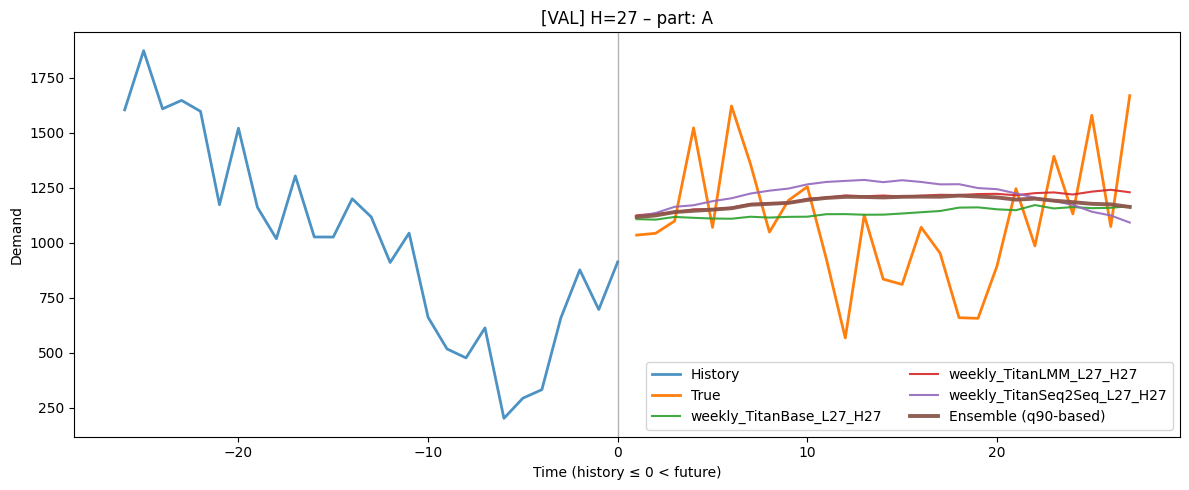

In [11]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=54, device=device)

pu.plot_27w(
    models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
    loader=val_loader,       # (xb, yb[, part_ids])
    device="cuda" if torch.cuda.is_available() else "cpu",
    mode="val",              # ← 검증 모드
    max_plots=1,
    out_dir=None,
    show=True,
    future_exo_cb=my_exo_cb
)